In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")


In [2]:
district_df = pd.read_csv("District_Monthly_Rainfall_1995_2025.csv")
tehsil_df = pd.read_csv("LahoreDivision_Tehsil_Rainfall_1995_2025.csv")

district_df.head(), tehsil_df.head()


(             system:index  CC_3   COUNTRY ENGTYPE_3 GID_0    GID_1      GID_2  \
 0  0_00000000000000000000   NaN  Pakistan  District   PAK  PAK.7_1  PAK.7.5_1   
 1  0_00000000000000000001   NaN  Pakistan  District   PAK  PAK.7_1  PAK.7.5_1   
 2  0_00000000000000000002   NaN  Pakistan  District   PAK  PAK.7_1  PAK.7.5_1   
 3  0_00000000000000000003   NaN  Pakistan  District   PAK  PAK.7_1  PAK.7.5_1   
 4  1_00000000000000000000   NaN  Pakistan  District   PAK  PAK.7_1  PAK.7.5_1   
 
          GID_3  HASC_3  NAME_1  ... NL_NAME_1 NL_NAME_2  NL_NAME_3    TYPE_3  \
 0  PAK.7.5.1_1     NaN  Punjab  ...       NaN       NaN        NaN  District   
 1  PAK.7.5.2_1     NaN  Punjab  ...       NaN       NaN        NaN  District   
 2  PAK.7.5.3_1     NaN  Punjab  ...       NaN       NaN        NaN  District   
 3  PAK.7.5.6_1     NaN  Punjab  ...       NaN       NaN        NaN  District   
 4  PAK.7.5.1_1     NaN  Punjab  ...       NaN       NaN        NaN  District   
 
    VARNAME_3     

In [3]:
district_df.columns

Index(['system:index', 'CC_3', 'COUNTRY', 'ENGTYPE_3', 'GID_0', 'GID_1',
       'GID_2', 'GID_3', 'HASC_3', 'NAME_1', 'NAME_2', 'NAME_3', 'NL_NAME_1',
       'NL_NAME_2', 'NL_NAME_3', 'TYPE_3', 'VARNAME_3', 'mean', 'month',
       'rainfall_mm', 'year', '.geo'],
      dtype='object')

In [4]:

tehsil_df.columns


Index(['system:index', 'adm0_name', 'adm0_name1', 'adm0_name2', 'adm0_name3',
       'adm0_pcode', 'adm1_name', 'adm1_name1', 'adm1_name2', 'adm1_name3',
       'adm1_pcode', 'adm2_name', 'adm2_name1', 'adm2_name2', 'adm2_name3',
       'adm2_pcode', 'adm3_name', 'adm3_name1', 'adm3_name2', 'adm3_name3',
       'adm3_pcode', 'adm3_ref_n', 'area_sqkm', 'center_lat', 'center_lon',
       'cod_versio', 'lang', 'lang1', 'lang2', 'lang3', 'mean', 'month',
       'rainfall_mm', 'valid_on', 'year', '.geo'],
      dtype='object')

In [5]:
print(district_df['NAME_3'].unique())
print(tehsil_df['adm3_name'].unique())


['Kasur' 'Lahore' 'Nankana Sahib' 'Sheikhupura']
['Chunian' 'Kasur' 'Pattoki' 'Lahore Cantt' 'Lahore City' 'Nankana Sahib'
 'Sangla Hill' 'Ferozewala' 'Muridke' 'Safdarabad' 'Sheikhupura']


In [6]:

district_df.columns = district_df.columns.str.strip().str.lower().str.replace(" ", "_")
tehsil_df.columns = tehsil_df.columns.str.strip().str.lower().str.replace(" ", "_")

district_df['name3'] = district_df['name_3'].str.strip()
tehsil_df['adm3_name'] = tehsil_df['adm3_name'].str.strip()


In [7]:
district_annual = (
    district_df
    .groupby(['name3', 'year'], as_index=False)['rainfall_mm']
    .sum()
)
tehsil_annual = (
    tehsil_df
    .groupby(['adm3_name', 'year'], as_index=False)['rainfall_mm']
    .sum()
)


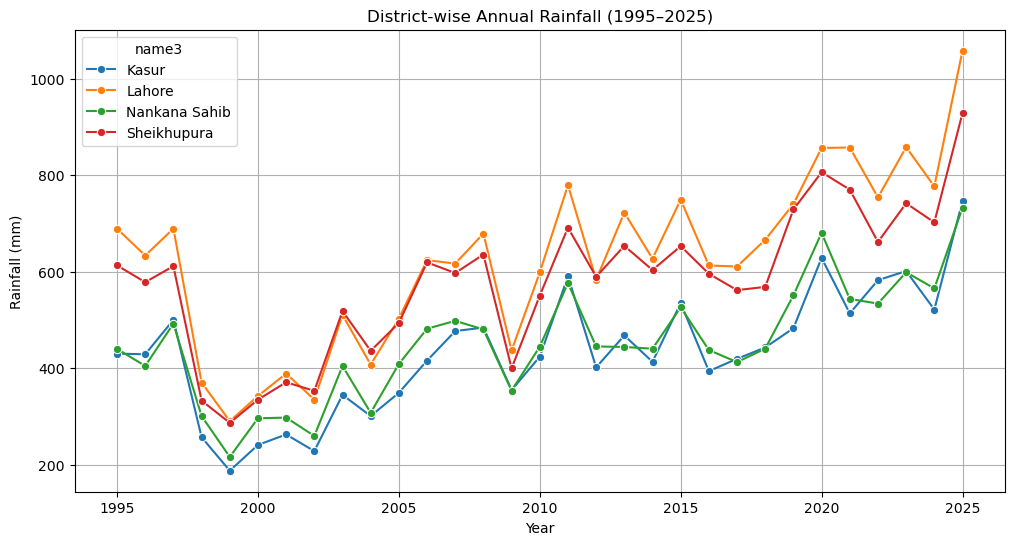

<Figure size 640x480 with 0 Axes>

In [8]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=district_annual,
    x='year',
    y='rainfall_mm',
    hue='name3',
    marker='o'
)
plt.title("District-wise Annual Rainfall (1995–2025)")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.grid(True)
plt.show()
plt.savefig("filename.png", dpi=300, bbox_inches='tight')


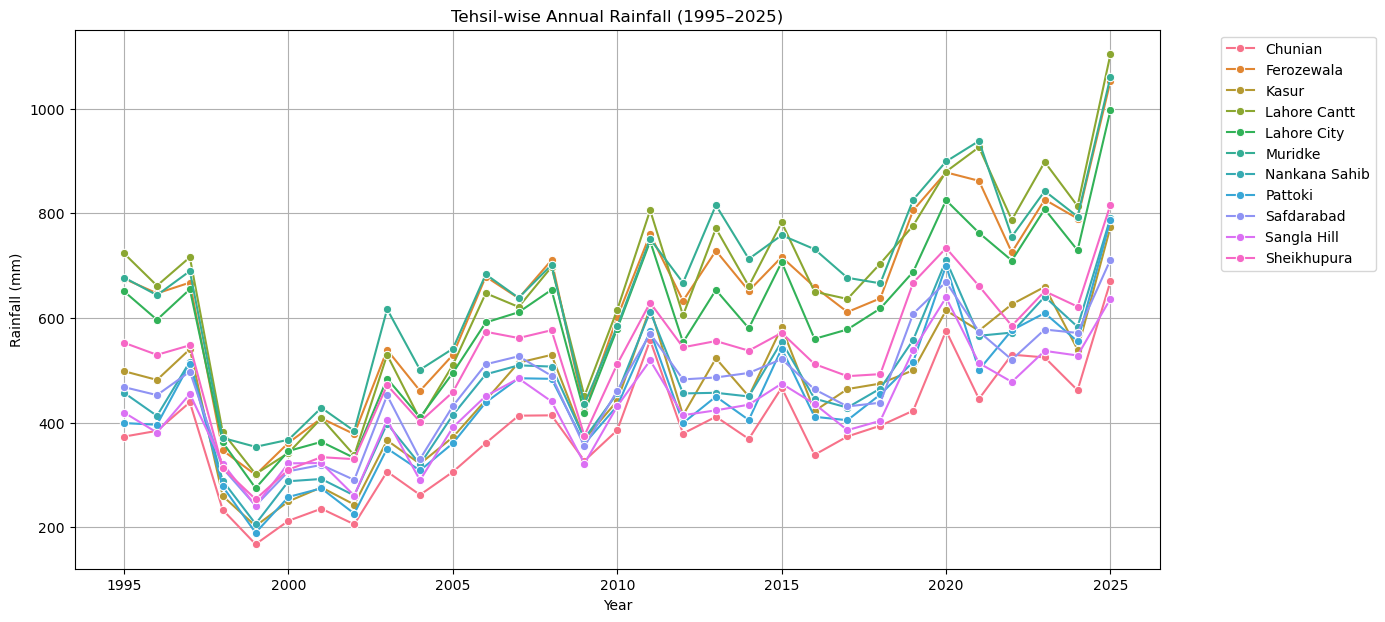

In [9]:
plt.figure(figsize=(14,7))
sns.lineplot(
    data=tehsil_annual,
    x='year',
    y='rainfall_mm',
    hue='adm3_name',
    marker='o'
)
plt.title("Tehsil-wise Annual Rainfall (1995–2025)")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.grid(True)
plt.savefig("filename.png", dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# District-wise monthly average (1995–2025)
district_month_avg = (
    district_df
    .groupby(['name3', 'month'], as_index=False)['rainfall_mm']
    .mean()
)

# Pivot table for heatmap
district_pivot = district_month_avg.pivot(index='name3', columns='month', values='rainfall_mm')


In [11]:
# Tehsil-wise monthly average (1995–2025)
tehsil_month_avg = (
    tehsil_df
    .groupby(['adm3_name', 'month'], as_index=False)['rainfall_mm']
    .mean()
)

# Pivot table for heatmap
tehsil_pivot = tehsil_month_avg.pivot(index='adm3_name', columns='month', values='rainfall_mm')


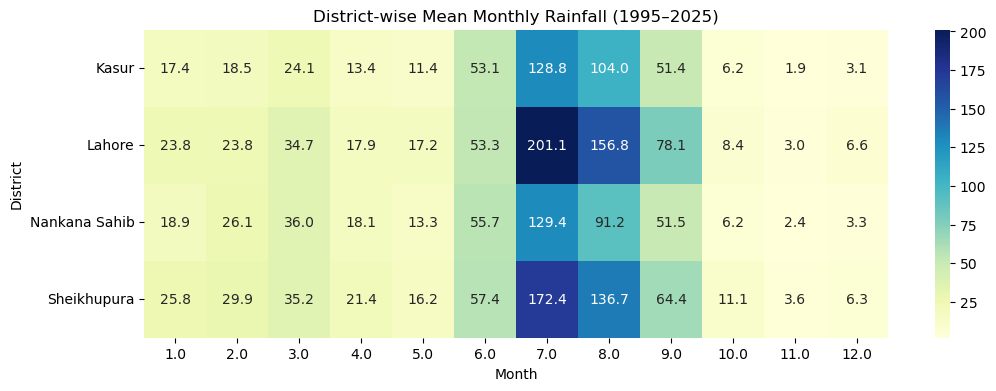

In [12]:
plt.figure(figsize=(12,4))
sns.heatmap(district_pivot, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("District-wise Mean Monthly Rainfall (1995–2025)")
plt.xlabel("Month")
plt.ylabel("District")
plt.show()


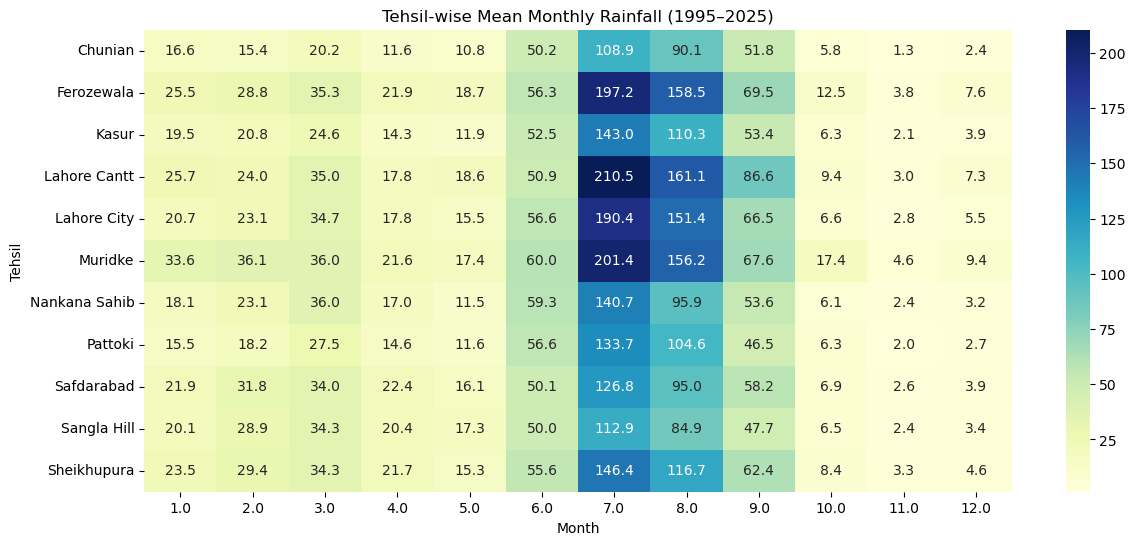

In [13]:
plt.figure(figsize=(14,6))
sns.heatmap(tehsil_pivot, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Tehsil-wise Mean Monthly Rainfall (1995–2025)")
plt.xlabel("Month")
plt.ylabel("Tehsil")
plt.show()


In [14]:
district_total = (
    district_df
    .groupby("name_3", as_index=False)["rainfall_mm"]
    .sum()
    .sort_values("rainfall_mm", ascending=False)
)


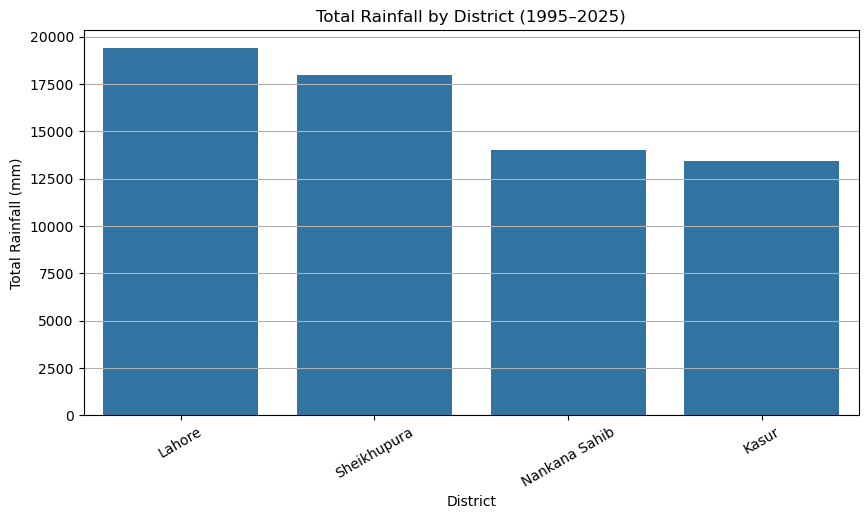

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(
    data=district_total,
    x="name_3",
    y="rainfall_mm"
)

plt.title("Total Rainfall by District (1995–2025)")
plt.xlabel("District")
plt.ylabel("Total Rainfall (mm)")
plt.xticks(rotation=30)
plt.grid(axis="y")

plt.savefig("district_total_rainfall_31years.png", dpi=300, bbox_inches="tight")
plt.show()


In [16]:
tehsil_total = (
    tehsil_df
    .groupby("adm3_name", as_index=False)["rainfall_mm"]
    .sum()
    .sort_values("rainfall_mm", ascending=False)
)


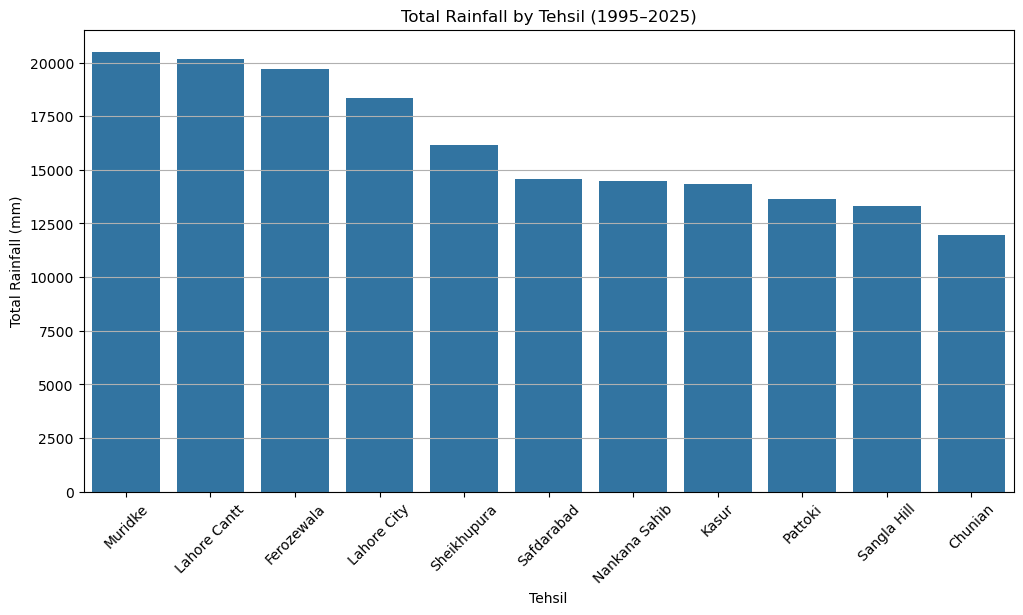

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(
    data=tehsil_total,
    x="adm3_name",
    y="rainfall_mm"
)

plt.title("Total Rainfall by Tehsil (1995–2025)")
plt.xlabel("Tehsil")
plt.ylabel("Total Rainfall (mm)")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.savefig("tehsil_total_rainfall_31years.png", dpi=300, bbox_inches="tight")
plt.show()


In [18]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4]:
        return "Spring"
    elif month in [5, 6]:
        return "Summer"
    elif month in [7, 8, 9]:
        return "Monsoon"
    elif month in [10, 11]:
        return "Autumn"


In [19]:
district_df["season"] = district_df["month"].apply(get_season)

In [20]:
tehsil_df["season"] = tehsil_df["month"].apply(get_season)

In [21]:
district_season_year_avg = (
    district_df
    .groupby(["year", "season"], as_index=False)["rainfall_mm"]
    .mean()
)


In [22]:
district_season_pivot = district_season_year_avg.pivot(
    index="year",
    columns="season",
    values="rainfall_mm"
)

district_season_pivot.head()


season,Autumn,Monsoon,Spring,Summer,Winter
year,,,,,
1995.0,1.473153,144.914150,24.616788,10.811521,11.537636
1996.0,1.604541,104.405467,19.453178,53.772991,16.179310
1997.0,19.083743,121.565646,25.474949,44.349100,10.313005
1998.0,5.647458,68.018353,21.249964,11.103230,11.773535
1999.0,0.428620,51.717293,10.675543,16.534776,11.654967


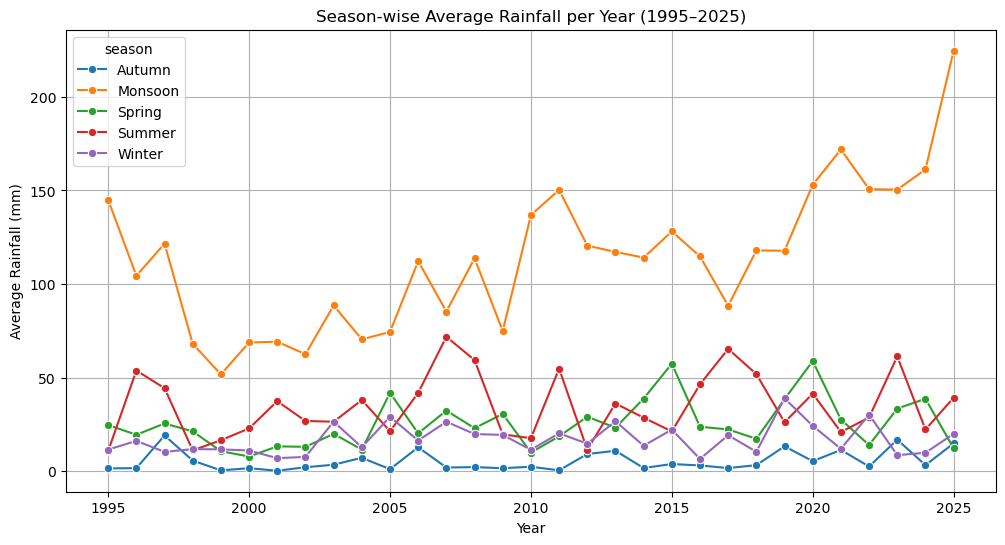

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.lineplot(
    data=district_season_year_avg,
    x="year",
    y="rainfall_mm",
    hue="season",
    marker="o"
)

plt.title("Season-wise Average Rainfall per Year (1995–2025)")
plt.xlabel("Year")
plt.ylabel("Average Rainfall (mm)")
plt.grid(True)

plt.savefig("seasonal_avg_rainfall_per_year.png", dpi=300, bbox_inches="tight")
plt.show()


In [24]:
district_season_total = (
    district_df
    .groupby("season", as_index=False)["rainfall_mm"]
    .sum()
)


In [25]:
total_rainfall = district_season_total["rainfall_mm"].sum()

district_season_total["percentage"] = (
    district_season_total["rainfall_mm"] / total_rainfall
) * 100


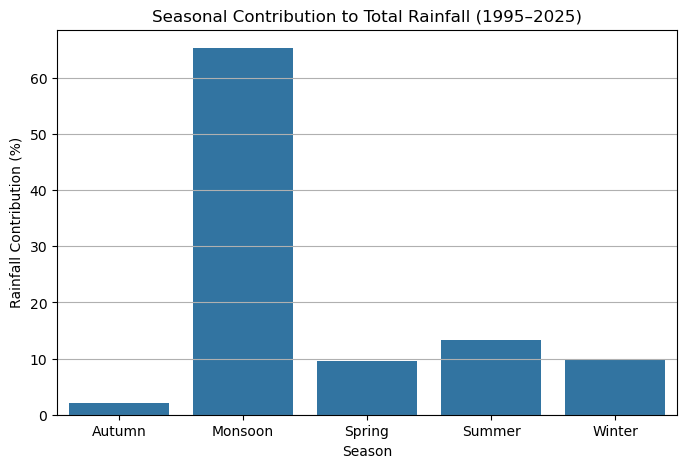

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(
    data=district_season_total,
    x="season",
    y="percentage"
)

plt.title("Seasonal Contribution to Total Rainfall (1995–2025)")
plt.xlabel("Season")
plt.ylabel("Rainfall Contribution (%)")
plt.grid(axis="y")

plt.savefig("seasonal_rainfall_contribution_percent.png", dpi=300, bbox_inches="tight")
plt.show()


In [27]:
monsoon_df = district_df[district_df["month"].isin([6, 7, 8, 9])]

In [28]:
ONSET_THRESHOLD = 50  # mm


In [29]:
def find_onset(group):
    valid = group[group["rainfall_mm"] >= ONSET_THRESHOLD]
    if valid.empty:
        return None
    return valid.sort_values("month").iloc[0]["month"]

monsoon_onset = (
    monsoon_df
    .groupby("year")
    .apply(find_onset)
    .reset_index(name="onset_month")
)


C:\Users\offic\AppData\Local\Temp\ipykernel_3136\1884787632.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(find_onset)


In [30]:
month_map = {
    6: "June",
    7: "July",
    8: "August",
    9: "September"
}

monsoon_onset["onset_month_name"] = monsoon_onset["onset_month"].map(month_map)


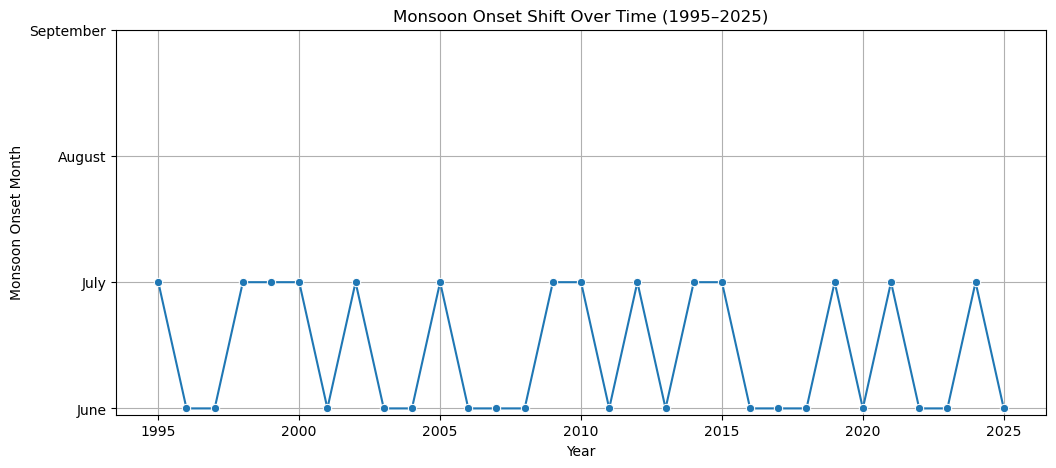

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))
sns.lineplot(
    data=monsoon_onset,
    x="year",
    y="onset_month",
    marker="o"
)

plt.yticks([6, 7, 8, 9], ["June", "July", "August", "September"])
plt.title("Monsoon Onset Shift Over Time (1995–2025)")
plt.xlabel("Year")
plt.ylabel("Monsoon Onset Month")
plt.grid(True)

plt.savefig("monsoon_onset_shift.png", dpi=300, bbox_inches="tight")
plt.show()


In [32]:
district_annual = (
    district_df
    .groupby(["name3", "year"], as_index=False)["rainfall_mm"]
    .sum()
)


In [33]:
district_mean = (
    district_annual
    .groupby("name3", as_index=False)["rainfall_mm"]
    .mean()
    .rename(columns={"rainfall_mm": "long_term_mean"})
)


In [34]:
district_anomaly = district_annual.merge(
    district_mean,
    on="name3"
)


In [35]:
district_anomaly["anomaly_mm"] = (
    district_anomaly["rainfall_mm"] -
    district_anomaly["long_term_mean"]
)


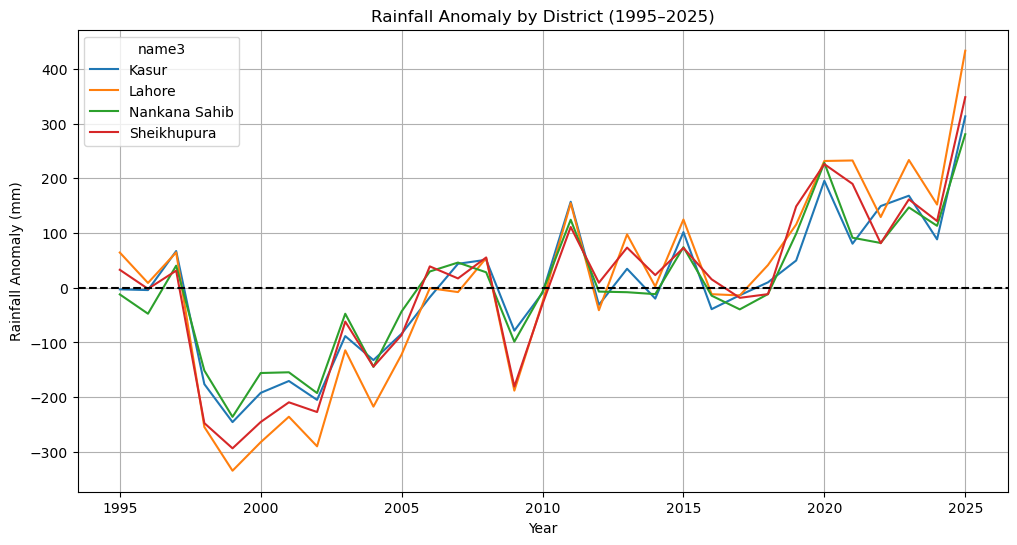

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.lineplot(
    data=district_anomaly,
    x="year",
    y="anomaly_mm",
    hue="name3"
)

plt.axhline(0, color="black", linestyle="--")
plt.title("Rainfall Anomaly by District (1995–2025)")
plt.xlabel("Year")
plt.ylabel("Rainfall Anomaly (mm)")
plt.grid(True)

plt.savefig("district_rainfall_anomaly.png", dpi=300, bbox_inches="tight")
plt.show()
